# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

今回は、PyTorch Geometricのイントロダクションで紹介されている下記のハンズオンを実行して理解を深める。

- []()

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)

In [ ]:
import numpy as np
import polars as pl
pl.Config.set_tbl_rows(-1)

df = pl.read_csv("./features.csv")
# Date列から年（YYYY）だけを取り出して抽出
df = df.with_columns(
    pl.col("Date").str.slice(0, 4).cast(pl.Int32).alias("year")
)
df = df.filter(pl.col("year") == 2026)
df = df.select(['RaceId','Teiban', 'PlayerNo', 'StartTime_5races', 'glicko2_rating_waku', "Teiban1WinRate",'ReverseRanking'])
df = df.with_columns([
    pl.col('StartTime_5races').fill_null(
        pl.col('StartTime_5races').mean().over('RaceId')).alias(
            'StartTime_5races'),
    pl.col('glicko2_rating_waku').fill_null(
        pl.col('glicko2_rating_waku').mean().over('RaceId')).alias(
            'glicko2_rating_waku')
])

# polarsの .apply() はSeriesには無いので、.map_elements() を使う、か全体で式として書く
df_kimari = df\
    .filter(pl.col("ReverseRanking") == 6)\
    .with_columns([
        pl.when(
            (pl.col("Teiban") == 1) & (pl.col("ReverseRanking") == 6)
        ).then(
            pl.lit('nige')
        ).otherwise(
            pl.lit('makuri')
        ).alias("pattern")
    ]).select(["RaceId", "pattern"])

df = df.join(df_kimari, "RaceId").sort("RaceId")


In [2]:
df.head(12)

RaceId,Teiban,PlayerNo,StartTime_5races,glicko2_rating_waku,ReverseRanking,pattern
str,i64,i64,f64,f64,i64,str
"""20260101_06_01""",5,3990,0.17,1343.778327,3,"""nige"""
"""20260101_06_01""",3,4073,0.108,1675.955084,5,"""nige"""
"""20260101_06_01""",6,4730,0.132,1317.481329,2,"""nige"""
"""20260101_06_01""",1,5034,0.12,1869.682234,6,"""nige"""
"""20260101_06_01""",2,5248,0.218,1489.19125,4,"""nige"""
"""20260101_06_01""",4,5349,0.178,848.248976,1,"""nige"""
"""20260101_06_02""",5,3489,0.134,1409.278913,6,"""makuri"""
"""20260101_06_02""",1,3932,0.164,1605.697469,1,"""makuri"""
"""20260101_06_02""",2,4207,0.144,1635.249026,2,"""makuri"""


In [3]:
df.tail(12)

RaceId,Teiban,PlayerNo,StartTime_5races,glicko2_rating_waku,ReverseRanking,pattern
str,i64,i64,f64,f64,i64,str
"""20260306_23_10""",2,3612,0.144,1558.813548,5,"""makuri"""
"""20260306_23_10""",4,3788,0.11,1517.61369,6,"""makuri"""
"""20260306_23_10""",6,4263,0.208,1309.606971,3,"""makuri"""
"""20260306_23_10""",5,4273,0.204,1324.3125,4,"""makuri"""
"""20260306_23_10""",3,4904,0.152,1483.42729,2,"""makuri"""
"""20260306_23_10""",1,5199,0.13,1685.512431,1,"""makuri"""
"""20260306_23_12""",6,3618,0.196,1340.587736,1,"""nige"""
"""20260306_23_12""",2,3952,0.166,1621.142256,2,"""nige"""
"""20260306_23_12""",1,4013,0.134,2082.160323,6,"""nige"""


## a

In [4]:
import torch
import polars as pl

from torch_geometric.data import Data

In [5]:
def build_edge_index(num_nodes=6):

    src = []
    dst = []

    for i in range(num_nodes):
        for j in range(num_nodes):

            if i != j:
                src.append(i)
                dst.append(j)

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    return edge_index

In [6]:
def build_edge_attr(race_df):

    lanes = race_df["Teiban"].to_numpy()
    st = race_df["StartTime_5races"].to_numpy()
    rating = race_df["glicko2_rating_waku"].to_numpy()

    edge_attr = []

    for i in range(6):
        for j in range(6):

            if i == j:
                continue

            lane_diff = abs(lanes[i] - lanes[j])
            st_diff = abs(st[i] - st[j])
            rating_diff = abs(rating[i] - rating[j])

            edge_attr.append(
                [lane_diff, st_diff, rating_diff]
            )

    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return edge_attr

In [7]:
def build_node_feature(race_df):

    x = race_df.select(
        [
            "StartTime_5races",
            "glicko2_rating_waku"
        ]
    ).to_numpy()

    x = torch.tensor(x, dtype=torch.float)

    return x

In [8]:
def build_rank_label(race_df):

    ranks = race_df["ReverseRanking"].to_numpy()

    ranks = torch.tensor(ranks, dtype=torch.long)

    return ranks

In [9]:
def build_graph(race_df):

    race_df = race_df.sort("Teiban")

    x = build_node_feature(race_df)

    edge_index = build_edge_index()

    edge_attr = build_edge_attr(race_df)

    ranks = build_rank_label(race_df)

    race_id = race_df["RaceId"][0]
    pattern = race_df["pattern"][0]

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        ranks=ranks,
        race_id=race_id,
        pattern=pattern
    )

    return data

In [10]:
graphs = []

for race_id, g in df.group_by("RaceId"):

    graph = build_graph(g)

    graphs.append(graph)

print(len(graphs))

9454


In [11]:
print(graphs[0])

Data(x=[6, 2], edge_index=[2, 30], edge_attr=[30, 3], ranks=[6], race_id='20260101_06_01', pattern='nige')


In [12]:
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv

loader = DataLoader(graphs, batch_size=32)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATv2Conv


class BoatRaceGNN(nn.Module):

    def __init__(
        self,
        node_dim=2,      # ノード特徴量数
        edge_dim=3,      # edge feature数
        hidden_dim=16,
        embed_dim=8
    ):
        super().__init__()

        # -------------------------
        # GATv2 layers
        # -------------------------

        self.gat1 = GATv2Conv(
            node_dim,
            hidden_dim,
            edge_dim=edge_dim
        )

        self.gat2 = GATv2Conv(
            hidden_dim,
            embed_dim,
            edge_dim=edge_dim
        )

        # -------------------------
        # 各艇スコア
        # -------------------------

        self.score_head = nn.Linear(embed_dim, 1)

    # -------------------------------------------------
    # forward
    # -------------------------------------------------

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        # -------------------------
        # GNN 1
        # -------------------------

        h = self.gat1(
            x,
            edge_index,
            edge_attr
        )

        h = F.relu(h)

        # -------------------------
        # GNN 2
        # -------------------------

        z = self.gat2(
            h,
            edge_index,
            edge_attr
        )

        # z = 各艇embedding
        # shape (6, embed_dim)

        # -------------------------
        # 各艇スコア
        # -------------------------

        scores = self.score_head(z).squeeze(-1)

        # scores shape (6)

        # -------------------------
        # race embedding
        # -------------------------

        mean_z = z.mean(dim=0)

        max_z = z.max(dim=0).values

        sorted_scores, _ = torch.sort(
            scores,
            descending=True
        )

        score_gaps = (
            sorted_scores[:-1]
            -
            sorted_scores[1:]
        )

        race_emb = torch.cat(
            [
                mean_z,
                max_z,
                sorted_scores,
                score_gaps
            ]
        )

        return z, scores, race_emb

In [14]:
from torch_geometric.loader import DataLoader

loader = DataLoader(graphs, batch_size=32, shuffle=True)

model = BoatRaceGNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

import torch


def plackett_luce_loss(scores, ranks):

    # ReverseRanking: 6が1着、1が6着なので降順で並べる
    order = torch.argsort(
        ranks,
        dim=1,
        descending=True
    )

    ordered_scores = scores.gather(
        1,
        order
    )

    n = ordered_scores.size(1)

    loss = 0

    for k in range(n):

        denom = torch.logsumexp(
            ordered_scores[:,k:],
            dim=1
        )

        loss += denom - ordered_scores[:,k]

    return loss.mean()

In [ ]:
epochs = 101

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        z, scores, race_emb = model(batch)

        scores = scores.view(batch.num_graphs,6)
        ranks = batch.ranks.view(batch.num_graphs,6)

        loss = plackett_luce_loss(
            scores,
            ranks
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"epoch {epoch} loss {total_loss:.4f}"
    )

epoch 0 loss 2182.1886
epoch 1 loss 1936.6465
epoch 2 loss 1934.5895
epoch 3 loss 1931.9031
epoch 4 loss 1927.4841
epoch 5 loss 1923.2602
epoch 6 loss 1919.2515
epoch 7 loss 1926.9440
epoch 8 loss 1931.5006
epoch 9 loss 1916.0752
epoch 10 loss 1916.2373
epoch 11 loss 1912.6665
epoch 12 loss 1933.5353
epoch 13 loss 1923.8482
epoch 14 loss 1922.3200
epoch 15 loss 1921.0080
epoch 16 loss 1918.9341
epoch 17 loss 1915.9685
epoch 18 loss 1913.7101
epoch 19 loss 1914.1680
epoch 20 loss 1914.0803
epoch 21 loss 1913.9580
epoch 22 loss 1911.9577
epoch 23 loss 1913.3686
epoch 24 loss 1910.9272
epoch 25 loss 1908.7717
epoch 26 loss 1910.1165
epoch 27 loss 1909.5171
epoch 28 loss 1903.8174
epoch 29 loss 1902.3852
epoch 30 loss 1899.8119
epoch 31 loss 1899.5879
epoch 32 loss 1906.4105
epoch 33 loss 1897.7432
epoch 34 loss 1898.1269
epoch 35 loss 1898.5632
epoch 36 loss 1897.3564
epoch 37 loss 1896.8693
epoch 38 loss 1895.3971
epoch 39 loss 1899.0468
epoch 40 loss 1893.2286
epoch 41 loss 1898.8185
ep

/Users/aki/miniforge3/envs/boatrace311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


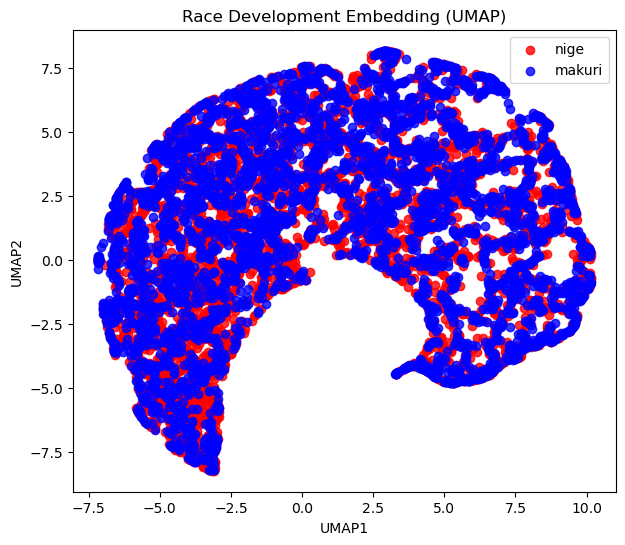

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

# -----------------------
# embedding取得
# -----------------------

model.eval()

race_embs = []
labels = []

for g in graphs:

    g = g.to(device)

    with torch.no_grad():
        _, _, race_emb = model(g)

    race_embs.append(race_emb.cpu().numpy())

    # Dataに保持したpatternをそのままラベルとして使う
    labels.append(g.pattern)

X = np.vstack(race_embs)

# -----------------------
# UMAP
# -----------------------

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

Z = reducer.fit_transform(X)

# -----------------------
# 可視化
# -----------------------

colors = {
    "nige": "red",
    "makuri": "blue"
}

plt.figure(figsize=(7,6))

for label in ["nige","makuri"]:

    idx = [i for i,l in enumerate(labels) if l==label]

    plt.scatter(
        Z[idx,0],
        Z[idx,1],
        c=colors[label],
        label=label,
        alpha=0.8
    )

plt.legend()
plt.title("Race Development Embedding (UMAP)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## 

/Users/aki/miniforge3/envs/boatrace311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  return math.isfinite(val)


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

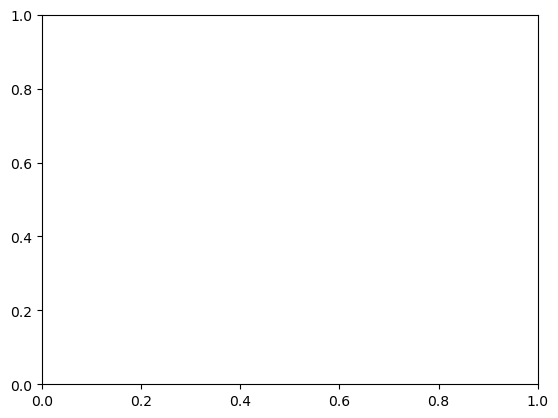

In [17]:
color = scores[:,0]

plt.scatter(
    Z[:,0],
    Z[:,1],
    c=color,
    cmap="turbo",
    s=20
)

plt.colorbar(label="boat1 score")
plt.show()